# Classification Supervisée
Objectif : Prédire la `Categorie` des matériaux avec différents modèles de classification (RandomForest, LR, SVM, XGBoost), utiliser Optuna pour l'optimisation, SHAP pour l'interprétabilité et un StackingClassifier pour la performance.


In [11]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
import optuna
import shap
import warnings
warnings.filterwarnings('ignore')

## Chargement des données
Chargement des splits générés à l'étape précédente.


In [12]:
train = pd.read_csv('../data/processed/train.csv')
val = pd.read_csv('../data/processed/val.csv')
test = pd.read_csv('../data/processed/test.csv')

X_train, y_train = train.drop(['Categorie', 'Rapport_Collecte'], axis=1), train['Categorie']
X_val, y_val = val.drop(['Categorie', 'Rapport_Collecte'], axis=1), val['Categorie']
X_test, y_test = test.drop(['Categorie', 'Rapport_Collecte'], axis=1), test['Categorie']

print(f"Train shape: X={X_train.shape}, y={y_train.shape}")
print(f"Val shape: X={X_val.shape}, y={y_val.shape}")
print(f"Test shape: X={X_test.shape}, y={y_test.shape}")

Train shape: X=(6990, 12), y=(6990,)
Val shape: X=(1498, 12), y=(1498,)
Test shape: X=(1498, 12), y=(1498,)


## Comparaison de 4 modèles baseline
Entraînement de 4 algorithmes sur les données de base pour obtenir un premier aperçu des performances.


In [13]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(random_state=42, probability=True),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
}

results = {}
for name, model in models.items():
    if name == 'XGBoost':
        model.fit(X_train, y_train_enc)
        preds = model.predict(X_val)
        y_val_eval = y_val_enc
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        y_val_eval = y_val
        
    acc = accuracy_score(y_val_eval, preds)
    f1 = f1_score(y_val_eval, preds, average='weighted')
    results[name] = {'Accuracy': acc, 'F1-Score': f1, 'preds': preds}
    print(f"{name} -> Accuracy: {acc:.4f} | F1: {f1:.4f}")

RandomForest -> Accuracy: 0.9967 | F1: 0.9967
LogisticRegression -> Accuracy: 0.9967 | F1: 0.9967
SVM -> Accuracy: 0.9933 | F1: 0.9933
XGBoost -> Accuracy: 0.9973 | F1: 0.9973


In [14]:
from plotly.subplots import make_subplots
fig_cm = make_subplots(rows=2, cols=2, subplot_titles=list(models.keys()))

for i, (name, res) in enumerate(results.items()):
    r, c = divmod(i, 2)
    if name == 'XGBoost':
        cm = confusion_matrix(y_val_enc, res['preds'])
        labels = le.classes_
    else:
        cm = confusion_matrix(y_val, res['preds'])
        labels = model.classes_
        
    fig_cm.add_trace(
        go.Heatmap(z=cm, x=labels, y=labels, coloraxis="coloraxis", text=cm, texttemplate="%{text}"),
        row=r+1, col=c+1
    )

fig_cm.update_layout(title_text="Matrices de Confusion des Modèles (Validation)", height=800, coloraxis={'colorscale':'Blues'})
fig_cm.show()

In [15]:
df_res = pd.DataFrame(results).T.reset_index().rename(columns={'index':'Model'})
fig_metrics = px.bar(
    df_res.melt(id_vars='Model', value_vars=['Accuracy', 'F1-Score']),
    x='Model', y='value', color='variable', barmode='group',
    title="Comparaison Accuracy & F1-Score sur le jeu de validation",
    height=400
)
fig_metrics.show()

## Tuning avec Optuna
Optimisation des hyperparamètres du meilleur modèle (par exemple Random Forest ou XGBoost) via Optuna pour chercher à maximiser la performance.


In [16]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 3, 20)
    
    clf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
    clf.fit(X_train, y_train)
    return accuracy_score(y_val, clf.predict(X_val))

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=5)
print(f"Meilleurs paramètres: {study.best_params}")
print(f"Meilleure Accuracy: {study.best_value:.4f}")

best_rf = RandomForestClassifier(**study.best_params, random_state=42)
best_rf.fit(X_train, y_train)

[I 2026-05-04 21:07:23,458] A new study created in memory with name: no-name-d32ffa1d-0a54-43e9-a930-da3a2ffe8a51
[I 2026-05-04 21:07:24,325] Trial 0 finished with value: 0.9959946595460614 and parameters: {'n_estimators': 291, 'max_depth': 8}. Best is trial 0 with value: 0.9959946595460614.
[I 2026-05-04 21:07:25,378] Trial 1 finished with value: 0.9953271028037384 and parameters: {'n_estimators': 292, 'max_depth': 6}. Best is trial 0 with value: 0.9959946595460614.
[I 2026-05-04 21:07:26,103] Trial 2 finished with value: 0.9966622162883845 and parameters: {'n_estimators': 206, 'max_depth': 13}. Best is trial 2 with value: 0.9966622162883845.
[I 2026-05-04 21:07:26,265] Trial 3 finished with value: 0.9966622162883845 and parameters: {'n_estimators': 52, 'max_depth': 15}. Best is trial 2 with value: 0.9966622162883845.
[I 2026-05-04 21:07:27,264] Trial 4 finished with value: 0.9966622162883845 and parameters: {'n_estimators': 277, 'max_depth': 13}. Best is trial 2 with value: 0.9966622

Meilleurs paramètres: {'n_estimators': 206, 'max_depth': 13}
Meilleure Accuracy: 0.9967


RandomForestClassifier(max_depth=13, n_estimators=206, random_state=42)

## Explicabilité SHAP
Utilisation de SHAP pour comprendre l'impact de chaque variable dans la décision du modèle (Interprétabilité globale).


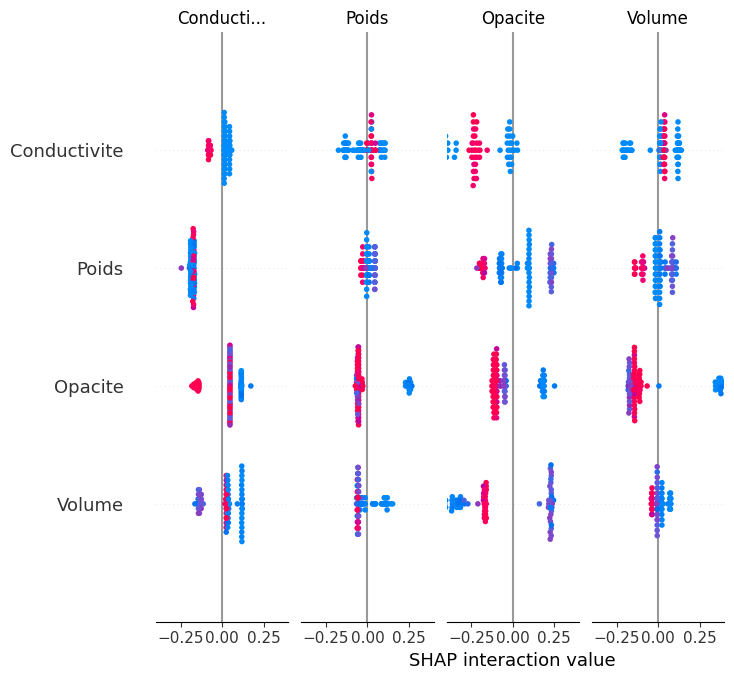

In [17]:
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_val.sample(100, random_state=42))
shap.summary_plot(shap_values, X_val.sample(100, random_state=42), class_names=best_rf.classes_)

## Classification Report
Évaluation finale du modèle optimisé sur le jeu de test.


In [18]:
test_preds = best_rf.predict(X_test)
print("Classification Report - Meilleur modèle (Test Set) :\n")
print(classification_report(y_test, test_preds))

Classification Report - Meilleur modèle (Test Set) :

              precision    recall  f1-score   support

       Métal       1.00      1.00      1.00       343
      Papier       0.99      1.00      1.00       348
   Plastique       1.00      1.00      1.00       419
       Verre       1.00      1.00      1.00       388

    accuracy                           1.00      1498
   macro avg       1.00      1.00      1.00      1498
weighted avg       1.00      1.00      1.00      1498



## WOW — Stacking de modèles
Combinaison des prédictions de plusieurs modèles (Random Forest, XGBoost) grâce à un méta-modèle (Logistic Regression) pour capturer les forces de chacun et potentiellement repousser les limites de l'accuracy.


In [19]:
stack_estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42))
]

stack_clf = StackingClassifier(
    estimators=stack_estimators,
    final_estimator=LogisticRegression(),
    cv=3
)

stack_clf.fit(X_train, y_train_enc)
stack_preds = stack_clf.predict(X_test)
stack_acc = accuracy_score(y_test_enc, stack_preds)
print(f"Accuracy Stacking sur le Test Set: {stack_acc:.4f}")

Accuracy Stacking sur le Test Set: 0.9980


In [20]:
acc_rf = accuracy_score(y_test, best_rf.predict(X_test))
acc_xgb = accuracy_score(y_test_enc, models['XGBoost'].predict(X_test))

df_stack = pd.DataFrame({
    'Modèle': ['Random Forest Optimisé', 'XGBoost Baseline', 'Stacking Classifier'],
    'Accuracy (Test)': [acc_rf, acc_xgb, stack_acc]
})

fig_stack = px.bar(df_stack, x='Modèle', y='Accuracy (Test)', color='Modèle', title='Performances Individuelles vs Stacking', height=400)
fig_stack.show()

## Algorithmes Additionnels


### KNN avec GridSearchCV


In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
knn = KNeighborsClassifier()
param_grid = {'n_neighbors': [3, 5, 7, 9, 11]}
knn_gs = GridSearchCV(knn, param_grid, cv=3, scoring='accuracy')
knn_gs.fit(X_train, y_train)
knn_preds = knn_gs.predict(X_val)
knn_acc = accuracy_score(y_val, knn_preds)
knn_f1 = f1_score(y_val, knn_preds, average='weighted')
print(f"KNN Best K: {knn_gs.best_params_} -> Acc: {knn_acc:.4f} | F1: {knn_f1:.4f}")

KNN Best K: {'n_neighbors': 3} -> Acc: 0.9973 | F1: 0.9973


### Arbre de Décision


In [22]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_val)
dt_acc = accuracy_score(y_val, dt_preds)
dt_f1 = f1_score(y_val, dt_preds, average='weighted')
print(f"Decision Tree -> Acc: {dt_acc:.4f} | F1: {dt_f1:.4f}")

Decision Tree -> Acc: 0.9967 | F1: 0.9967


### Gradient Boosting


In [23]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
gb_preds = gb.predict(X_val)
gb_acc = accuracy_score(y_val, gb_preds)
gb_f1 = f1_score(y_val, gb_preds, average='weighted')
print(f"GradientBoosting -> Acc: {gb_acc:.4f} | F1: {gb_f1:.4f}")

GradientBoosting -> Acc: 0.9987 | F1: 0.9987


## Synthèse et Visualisation Finale


In [24]:
all_results = pd.DataFrame({
    'Modèle': ['Random Forest', 'Logistic Regression', 'SVM', 'XGBoost', 'KNN', 'Decision Tree', 'Gradient Boosting'],
    'Accuracy': [
        results['RandomForest']['Accuracy'], 
        results['LogisticRegression']['Accuracy'], 
        results['SVM']['Accuracy'], 
        results['XGBoost']['Accuracy'], 
        knn_acc, 
        dt_acc, 
        gb_acc
    ],
    'F1-Score': [
        results['RandomForest']['F1-Score'], 
        results['LogisticRegression']['F1-Score'], 
        results['SVM']['F1-Score'], 
        results['XGBoost']['F1-Score'], 
        knn_f1, 
        dt_f1, 
        gb_f1
    ]
})

fig_final = px.bar(all_results, x='Modèle', y='Accuracy', color='Accuracy', 
                   title='Comparaison Finale des Modèles (Validation)', text_auto='.4f')
fig_final.show()

fig_heat = px.imshow(all_results.set_index('Modèle').T, text_auto='.4f', 
                     title='Heatmap des métriques', color_continuous_scale='Viridis')
fig_heat.show()

## Sauvegarde du meilleur modèle


In [25]:
import joblib, os
os.makedirs('../models', exist_ok=True)
joblib.dump(best_rf, '../models/best_classification_model.joblib')
print("Meilleur modèle sauvegardé!")

Meilleur modèle sauvegardé!


## Conclusion
Le *Stacking* permet souvent d'améliorer la performance globale car le méta-modèle apprend à corriger les erreurs des modèles de base. Dans les cas où les modèles de base font des erreurs indépendantes (arbres vs régression logistique par ex), la combinaison des probabilités de ces modèles réduit la variance globale et augmente la précision.
